In [7]:
import sys
sys.path.append('../')
import numpy as np
import pandas as pd
import sgpe
import ordpy
import math
import time
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
# Read in data
centers_df = pd.read_csv('../data/state_populationcenters_distance.csv')
centers_df['origin'] = centers_df['origin'].astype(str)
centers_df['destination'] = centers_df['destination'].astype(str)

cases_df = pd.read_csv('../data/covid19_incident_hosp_normalized.csv', parse_dates=['date']).set_index('date')

In [11]:
ds_vals = list(range(1,10))
dt_vals = list(range(1,10))
taus_vals = list(range(1,11))
taut_vals =  list(range(1,11))

In [15]:
comparison_df = pd.DataFrame()
mean_nsgpe = []
svar_nsgpe = []
mean_sgpe = []
svar_sgpe = []
ds_list = []
dt_list = []
taus_list = []
taut_list = []
for ds in ds_vals:
    for dt in dt_vals:
        if ds==1 and dt==1:
            mean_sgpe.append(1)
            svar_sgpe.append(0)
            mean_nsgpe.append(1)
            svar_nsgpe.append(0)
            ds_list.append(ds)
            dt_list.append(dt)
        else: 
            entropy = cases_df.apply(lambda x: sgpe.calculate(x.name, cases_df, 
                                                              centers_df, ds=ds, dt=dt,
                                                              taut=1,taus=1,t_type="1d",
                                                              normalize=False))
            entropy_normalize = cases_df.apply(lambda x: sgpe.calculate(x.name, cases_df, 
                                                              centers_df, ds=ds, dt=dt,
                                                              taut=1,taus=1,t_type="1d",
                                                                       normalize=True))
            mean_sgpe.append(np.mean(entropy))
            svar_sgpe.append(np.var(entropy))
            mean_nsgpe.append(np.mean(entropy_normalize))
            svar_nsgpe.append(np.var(entropy_normalize))
            ds_list.append(ds)
            dt_list.append(dt)

comparison_df["dt"] = dt_list
comparison_df["ds"] = ds_list
comparison_df["mean_reg"] = mean_sgpe
comparison_df["svar_reg"] = svar_sgpe
comparison_df["mean_mod"] = mean_nsgpe
comparison_df["svar_mod"] = svar_nsgpe
comparison_df.to_csv("../plots/heatmap_data.csv",index=False)

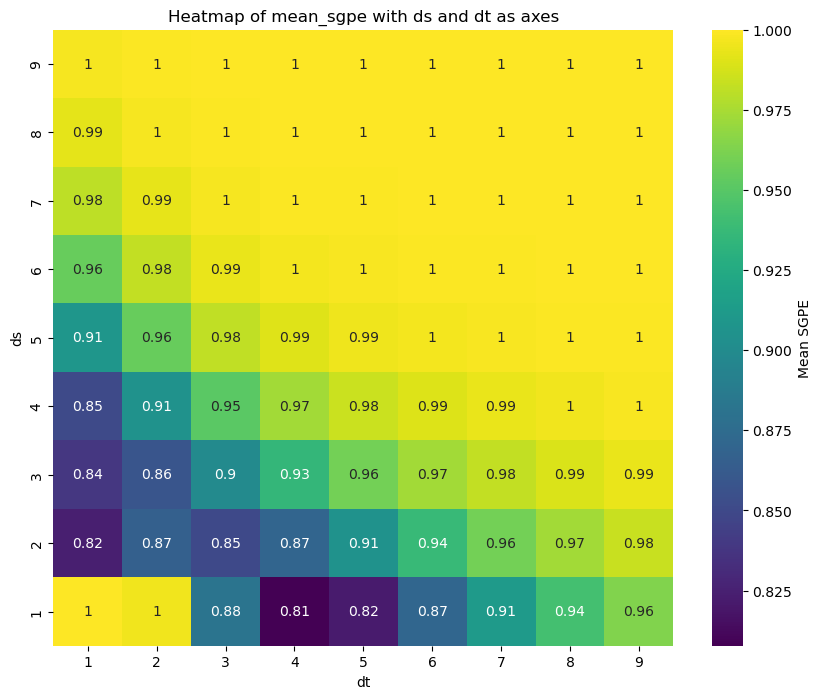

In [19]:
# Reshape the DataFrame for heatmap
heatmap_data = comparison_df.pivot(index="ds", columns="dt", values="mean_reg")
# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap="viridis", cbar_kws={'label': 'Mean SGPE'})
plt.xlabel("dt")
plt.ylabel("ds")
plt.title("Heatmap of mean_sgpe with ds and dt as axes")
plt.gca().invert_yaxis()
plt.show()

In [21]:
comparison_df2 = pd.DataFrame()
mean_nsgpe = []
svar_nsgpe = []
mean_sgpe = []
svar_sgpe = []
ds_list = []
dt_list = []
taus_list = []
taut_list = []
ds = 2
dt = 3
for taus in taus_vals:
    for taut in taut_vals:
        entropy_normalize = cases_df.apply(lambda x: sgpe.calculate(x.name, cases_df, 
                                                          centers_df, ds=ds, dt=dt,
                                                          taut=taut,taus=taus,t_type="1d"))
        mean_nsgpe.append(np.mean(entropy_normalize))
        svar_nsgpe.append(np.var(entropy_normalize))
        taus_list.append(taus)
        taut_list.append(taut)

comparison_df2["taut"] = taut_list
comparison_df2["taus"] = taus_list
comparison_df2["mean_mod"] = mean_nsgpe
comparison_df2["svar_mod"] = svar_nsgpe

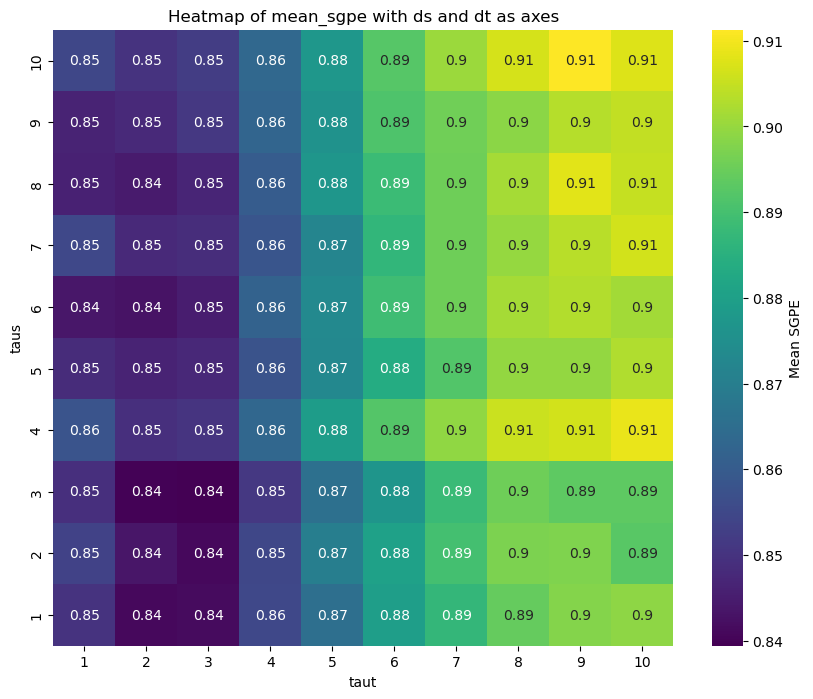

In [23]:
# Reshape the DataFrame for heatmap
heatmap_data = comparison_df2.pivot(index="taus", columns="taut", values="mean_mod")
# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap="viridis", cbar_kws={'label': 'Mean SGPE'})
plt.xlabel("taut")
plt.ylabel("taus")
plt.title("Heatmap of mean_sgpe with ds and dt as axes")
plt.gca().invert_yaxis()
plt.show()

In [42]:
comparison_df2 = pd.DataFrame()
mean_nsgpe2 = []
svar_nsgpe2 = []
mean_sgpe2 = []
svar_sgpe2 = []
ds_list2 = []
dt_list2 = []
taus_list = []
taut_list = []
for ds in ds_vals:
    for dt in dt_vals:
        if ds==1 and dt==1:
            mean_sgpe2.append(1)
            svar_sgpe2.append(0)
            mean_nsgpe2.append(1)
            svar_nsgpe2.append(0)
            ds_list2.append(ds)
            dt_list2.append(dt)
        else: 
            entropy = cases_df.apply(lambda x: sgpe.calculate(x.name, cases_df, 
                                                              centers_df, ds=ds, dt=dt,
                                                              taut=1,taus=1,t_type="2d",
                                                              normalize=False))
            entropy_normalize = cases_df.apply(lambda x: sgpe.calculate(x.name, cases_df, 
                                                              centers_df, ds=ds, dt=dt,
                                                              taut=1,taus=1,t_type="2d"))
            mean_sgpe2.append(np.mean(entropy/np.log2(float(math.factorial(ds*dt)))))
            svar_sgpe2.append(np.var(entropy/np.log2(float(math.factorial(ds*dt)))))
            mean_nsgpe2.append(np.mean(entropy_normalize))
            svar_nsgpe2.append(np.var(entropy_normalize))
            ds_list2.append(ds)
            dt_list2.append(dt)

comparison_df2["dt"] = dt_list2
comparison_df2["ds"] = ds_list2
comparison_df2["mean_reg"] = mean_sgpe2
comparison_df2["svar_reg"] = svar_sgpe2
comparison_df2["mean_mod"] = mean_nsgpe2
comparison_df2["svar_mod"] = svar_nsgpe2

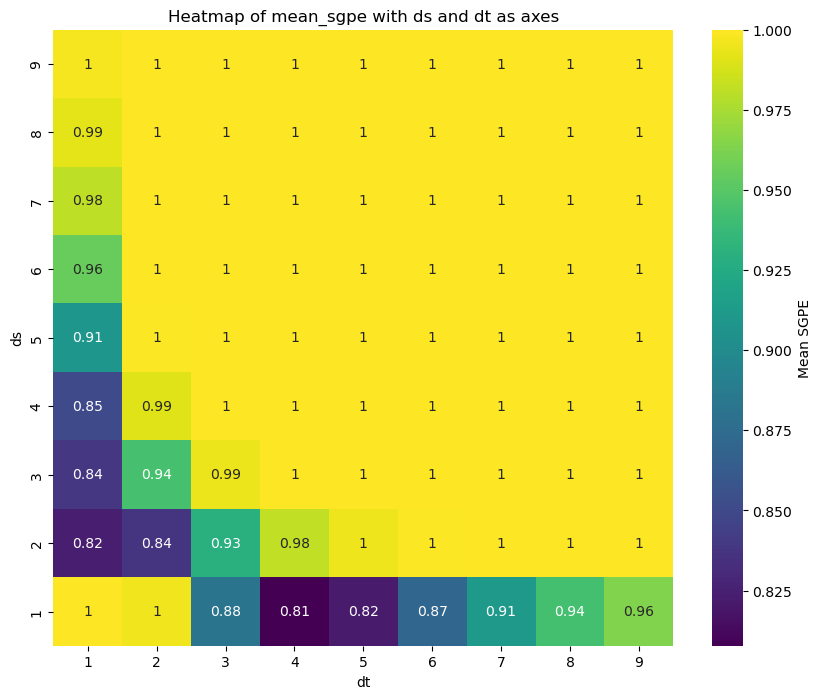

In [43]:
# Reshape the DataFrame for heatmap
heatmap_data = comparison_df2.pivot(index="ds", columns="dt", values="mean_mod")
# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap="viridis", cbar_kws={'label': 'Mean SGPE'})
plt.xlabel("dt")
plt.ylabel("ds")
plt.title("Heatmap of mean_sgpe with ds and dt as axes")
plt.gca().invert_yaxis()
plt.show()

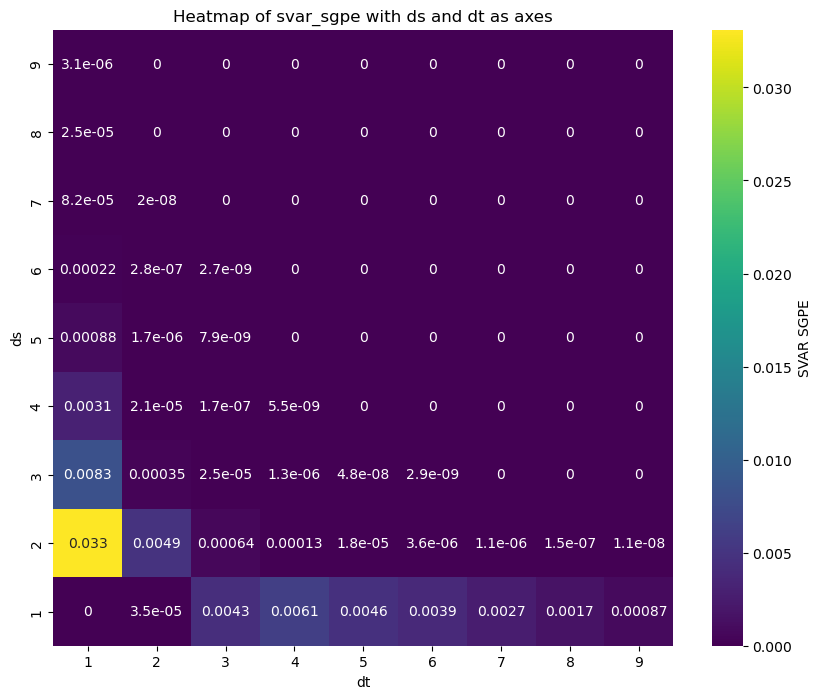

In [48]:
# Reshape the DataFrame for heatmap
heatmap_data = comparison_df2.pivot(index="ds", columns="dt", values="svar_mod")
# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap="viridis", cbar_kws={'label': 'SVAR SGPE'})
plt.xlabel("dt")
plt.ylabel("ds")
plt.title("Heatmap of svar_sgpe with ds and dt as axes")
plt.gca().invert_yaxis()
plt.show()

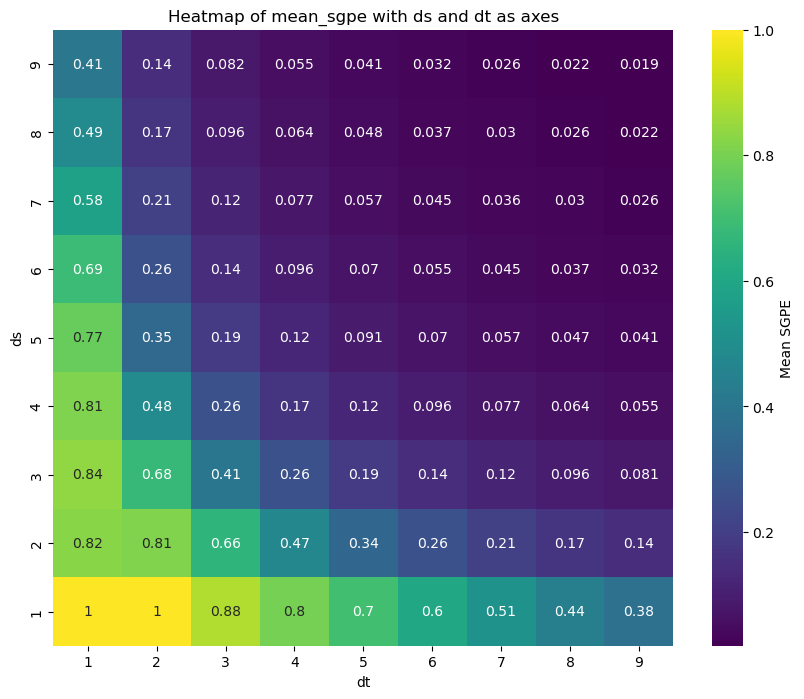

In [46]:
# Reshape the DataFrame for heatmap
heatmap_data = comparison_df2.pivot(index="ds", columns="dt", values="mean_reg")
# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap="viridis", cbar_kws={'label': 'Mean SGPE'})
plt.xlabel("dt")
plt.ylabel("ds")
plt.title("Heatmap of mean_sgpe with ds and dt as axes")
plt.gca().invert_yaxis()
plt.show()